<a href="https://colab.research.google.com/github/daniel-usp/USP/blob/main/Lei_de_Okun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Qual é a sensibilidade da taxa de desemprego em relação ao crescimento econômico?

A Lei de Okun é uma relação empírica que busca quantificar a relação entre a taxa de desemprego e a taxa de crescimento econômico. Ela foi proposta pelo economista Arthur Okun na década de 1960 e está presente em diversos livros textos de graduação. Buscamos através deste artigo investigar duas formas da Lei de Okun, descrevendo-a utilizando dados do Brasil. Usamos o Python para realizar todo o processo de análise de dados.

Relações empíricas relacionadas ao desemprego têm fascinado os economistas por muito tempo. Por exemplo, a curva de Phillips começou como uma simples observação de *trade-off* entre desemprego e inflação. No entanto, à medida que a teoria se alinhou com as evidências, a curva de Phillips emergiu como a relação mais importante na maneira como os economistas enxergam o lado da oferta da economia e está incorporada em todos os principais modelos macroeconômicos que orientam as políticas atualmente.

Outra relação de interesse para os economistas é aquela entre produção e desemprego. Em 1962, Arthur Okun observou duas relações empíricas:

  - as mudanças trimestrais na taxa de desemprego estavam relacionadas ao crescimento trimestral do produto interno bruto (PIB) real
  
  - desvios na taxa de desemprego estavam relacionados aos desvios do PIB em relação ao seu potencial (isto é, o Hiato do Produto)

Essas relações ficaram conhecidas como as versões *differences* e *gaps* da Lei de Okun, respectivamente.

A Lei de Okun é considerada uma relação estatística em vez de uma característica estrutural da economia, uma vez que tornou-se instável a sua aplicação. Isso corrobora como qualquer tipo de relação estatística, que pode estar sujeita a rupturas estruturais ou mudanças de regime. Por exemplo, mudanças estruturais no mercado de trabalho que levam a alterações na taxa de desemprego não aceleradora de inflação (NAIRU) são consideradas capazes de modificar o nível de equilíbrio do desemprego e alterar o trade-off entre inflação e produção. Embora esses choques do lado da oferta estejam cada vez mais integrados à teoria econômica, as rupturas estruturais na relação entre produção e desemprego limitaram o uso da Lei de Okun como uma regra de previsão.

Embora esses problemas tenham diminuido a confiança no uso da Lei de Okun, ainda podemos utiliza-la como uma regra de bolso simples e prática.

No presente exercício vamos empregar a Lei de Okun em sua versão output gap para dados do Brasil. O objetivo será não somente obter o coeficiente para toda a amostra, mas também criar de defasagem distribuidas e o coeficiente em janelas deslizantes.

Para dados do desemprego utilizaremos a Taxa de Desocupação medida pela PNADc ampliada e dessazonalizada, criada pelo exercício ["Ampliando a série da PNADc"](https://analisemacro.com.br/economia/macroeconometria/taxa-de-desemprego-pnad-continua-vs-pme-2/) da Análise Macro. A importância de uma série ampliada permite que tenhamos uma amostra de tamanho suficiente, visto que utilizaremos dados trimestrais e a série da PNADc tem início em 2012.

Para dados de crescimento usamos o Hiato do Produto, capturamos os dados produzidos pelo Banco Central do Brasil, obtido através do Relatório de Inflação.


# 1. Carregamento das bibliotecas

In [ ]:
# Carrega bibliotecas
import pandas as pd
from plotnine import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS
from functools import reduce # módulo para juntar dfs

# 2. Coleta e Tratamento de dados

## 2.1 Taxa de Desocupação

In [ ]:
# Taxa de desocupação Ampliada - PNADc - Dessazonalizada
pnad = pd.read_csv("https://aluno.analisemacro.com.br/download/56996/?tmstv=1701898596", parse_dates = ['Date'])

In [ ]:
pnad

,Date,pnad,pnad_ampliada_sa
0,2002-03-01,13.819814,13.260005
1,2002-04-01,13.464640,12.814436
2,2002-05-01,12.918810,12.529486
3,2002-06-01,12.654990,12.499258
4,2002-07-01,12.905206,12.867762
...,...,...,...
255,2023-06-01,8.000000,7.981787
256,2023-07-01,7.900000,7.900710
257,2023-08-01,7.800000,7.842824
258,2023-09-01,7.700000,7.791253


In [ ]:
# Trimestraliza a série da Taxa de Desocupação
pnad_tri = (
    pnad
    .set_index('Date')
    .resample('Q') # resample da data para trimestral
    .last() # captura o último valor do trimestre
    .reset_index()
    .assign(Date = lambda x : pd.PeriodIndex(x.Date, freq = 'Q'))
)

pnad_tri

,Date,pnad,pnad_ampliada_sa
0,2002Q1,13.819814,13.260005
1,2002Q2,12.654990,12.499258
2,2002Q3,12.579801,12.529589
3,2002Q4,11.728752,12.917559
4,2003Q1,13.128146,12.595953
...,...,...,...
83,2022Q4,7.900000,8.335203
84,2023Q1,8.800000,8.321874
85,2023Q2,8.000000,7.981787
86,2023Q3,7.700000,7.791253


## 2.2 Hiato do Produto - BCB

In [ ]:
# Coleta e tratamento do Hiato do Produto do BCB
hiato = (
    pd.read_excel(
    "https://www.bcb.gov.br/content/ri/relatorioinflacao/202309/ri202309anp.xlsx",
    sheet_name = "Graf 2.2.4",
    skiprows = 8
    )
    .assign(Date = lambda x: pd.PeriodIndex(x['Trimestre'], freq = 'Q'),
            hiato = lambda x: x.Hiato.astype(float))
    .loc[:, ['Date', 'hiato']]
  )

hiato

,Date,hiato
0,2003Q4,-0.82
1,2004Q1,-0.39
2,2004Q2,-0.02
3,2004Q3,0.37
4,2004Q4,0.64
...,...,...
75,2022Q3,-0.57
76,2022Q4,-0.59
77,2023Q1,-0.64
78,2023Q2,-0.66


## 2.3 Junta os dados

In [ ]:
# lista de dataframes
dfs = [pnad_tri, hiato]

# reduz os dataframes pela chave 'date_quarter' com left join
dados_reg = reduce(lambda left, right: pd.merge(left, right, on = 'Date', how = 'left'), dfs).dropna()

# Altera o tipo da coluna de data
dados_reg['Date'] = dados_reg.Date.dt.to_timestamp()

dados_reg

,Date,pnad,pnad_ampliada_sa,hiato
7,2003-10-01,12.049487,13.300615,-0.82
8,2004-01-01,13.719887,13.171185,-0.39
9,2004-04-01,12.789576,12.638020,-0.02
10,2004-07-01,12.083558,12.072214,0.37
11,2004-10-01,10.960344,12.136884,0.64
...,...,...,...,...
82,2022-07-01,8.700000,8.780531,-0.57
83,2022-10-01,7.900000,8.335203,-0.59
84,2023-01-01,8.800000,8.321874,-0.64
85,2023-04-01,8.000000,7.981787,-0.66


# Lei de Okun: output gap

Esta versão da lei relaciona as mudanças na taxa de desemprego ao hiato entre a produção real e a produção potencial ou tendencial. Portanto, se a produção cair abaixo do potencial, abrindo um hiato negativo, espera-se que o desemprego aumente. Vice-versa, quando a produção real está acima da tendência ou potencial e surge um hiato positivo, espera-se que o desemprego diminua. Semelhante à versão differences, isso enfatiza a importância do ciclo econômico na determinação das mudanças no desemprego.

No entanto, não há uma definição universal do que constitui a produção 'tendencial' ou 'potencial', mas geralmente se pensa como sendo o nível de produção uma vez que medidas cíclicas e idiossincráticas foram removidas. Nesse sentido, é um nível de equilíbrio de produção no qual a economia pode crescer sem experimentar pressões inflacionárias ou deflacionárias. Outra maneira de expressar isso é definir a produção tendencial como o nível de produção consistente com o desemprego estando em sua NAIRU. Quando a produção ultrapassa a tendência, o desemprego cai abaixo de sua NAIRU e vice-versa.

$$U_t - U_{t}^{*} = \alpha + \beta \cdot (Y_t - Y_{t}^{*})$$

Onde:
- $ U_t $ é a taxa de desemprego no período $ t $,
- $ U_{t}^{*} $ é a taxa de desemprego no estado estacionário (ou NAIRU) no período $ t $,
- $ Y_t $ é o PIB real no período $ t $,
- $ Y_{t}^{*} $ é o PIB potencial no período $ t $,
- $ \beta $ é um coeficiente que representa a sensibilidade da taxa de desemprego aos desvios do PIB em relação ao seu potencial.

O problema nesta versão se concentra na impossibilidade de observar diretamente o produto potencial e a NAIRU, sendo necessário estimativas dessas medidas, o que pode tornar os valores da relação diferentes para cada diferentes método empregado para realizar a estimação.

Para o caso do Hiato, utilizaremos os dados disponbilizados pelo BCB, que estima o produto potencial através de uma função de produção. Para a NAIRU, utilizaremos o filtro hp, que permite remover oscilações, suavizando inovações de curto prazo (cíclicas e idiossincráticas).

### NAIRU

In [ ]:
# Calcula o filtro HP
filtro_hp = sm.tsa.filters.hpfilter(x = dados_reg['pnad_ampliada_sa'], lamb = 1600)

# Salva a tendência calculada
dados_reg['nairu'] = filtro_hp[1] # posição 1 é a tendência (0=ciclo);
dados_reg

,Date,pnad,pnad_ampliada_sa,hiato,nairu
7,2003-10-01,12.049487,13.300615,-0.82,12.840809
8,2004-01-01,13.719887,13.171185,-0.39,12.654932
9,2004-04-01,12.789576,12.638020,-0.02,12.469343
10,2004-07-01,12.083558,12.072214,0.37,12.284652
11,2004-10-01,10.960344,12.136884,0.64,12.101573
...,...,...,...,...,...
82,2022-07-01,8.700000,8.780531,-0.57,10.290672
83,2022-10-01,7.900000,8.335203,-0.59,9.948370
84,2023-01-01,8.800000,8.321874,-0.64,9.601595
85,2023-04-01,8.000000,7.981787,-0.66,9.252636


In [ ]:
# Calcula o Hiato do desemprego
dados_reg['u_gap'] = dados_reg['pnad_ampliada_sa'] - dados_reg['nairu']


## Relação output gap x hiato do desemprego

Através do gráfico de dispersão abaixo, podemos confirmar que há a relação inversa contemporânea, proposta pela Lei de Okun. Esta evidência é corroborada ao analisarmos o hiato do desemprego e do produto ao longo do tempo.

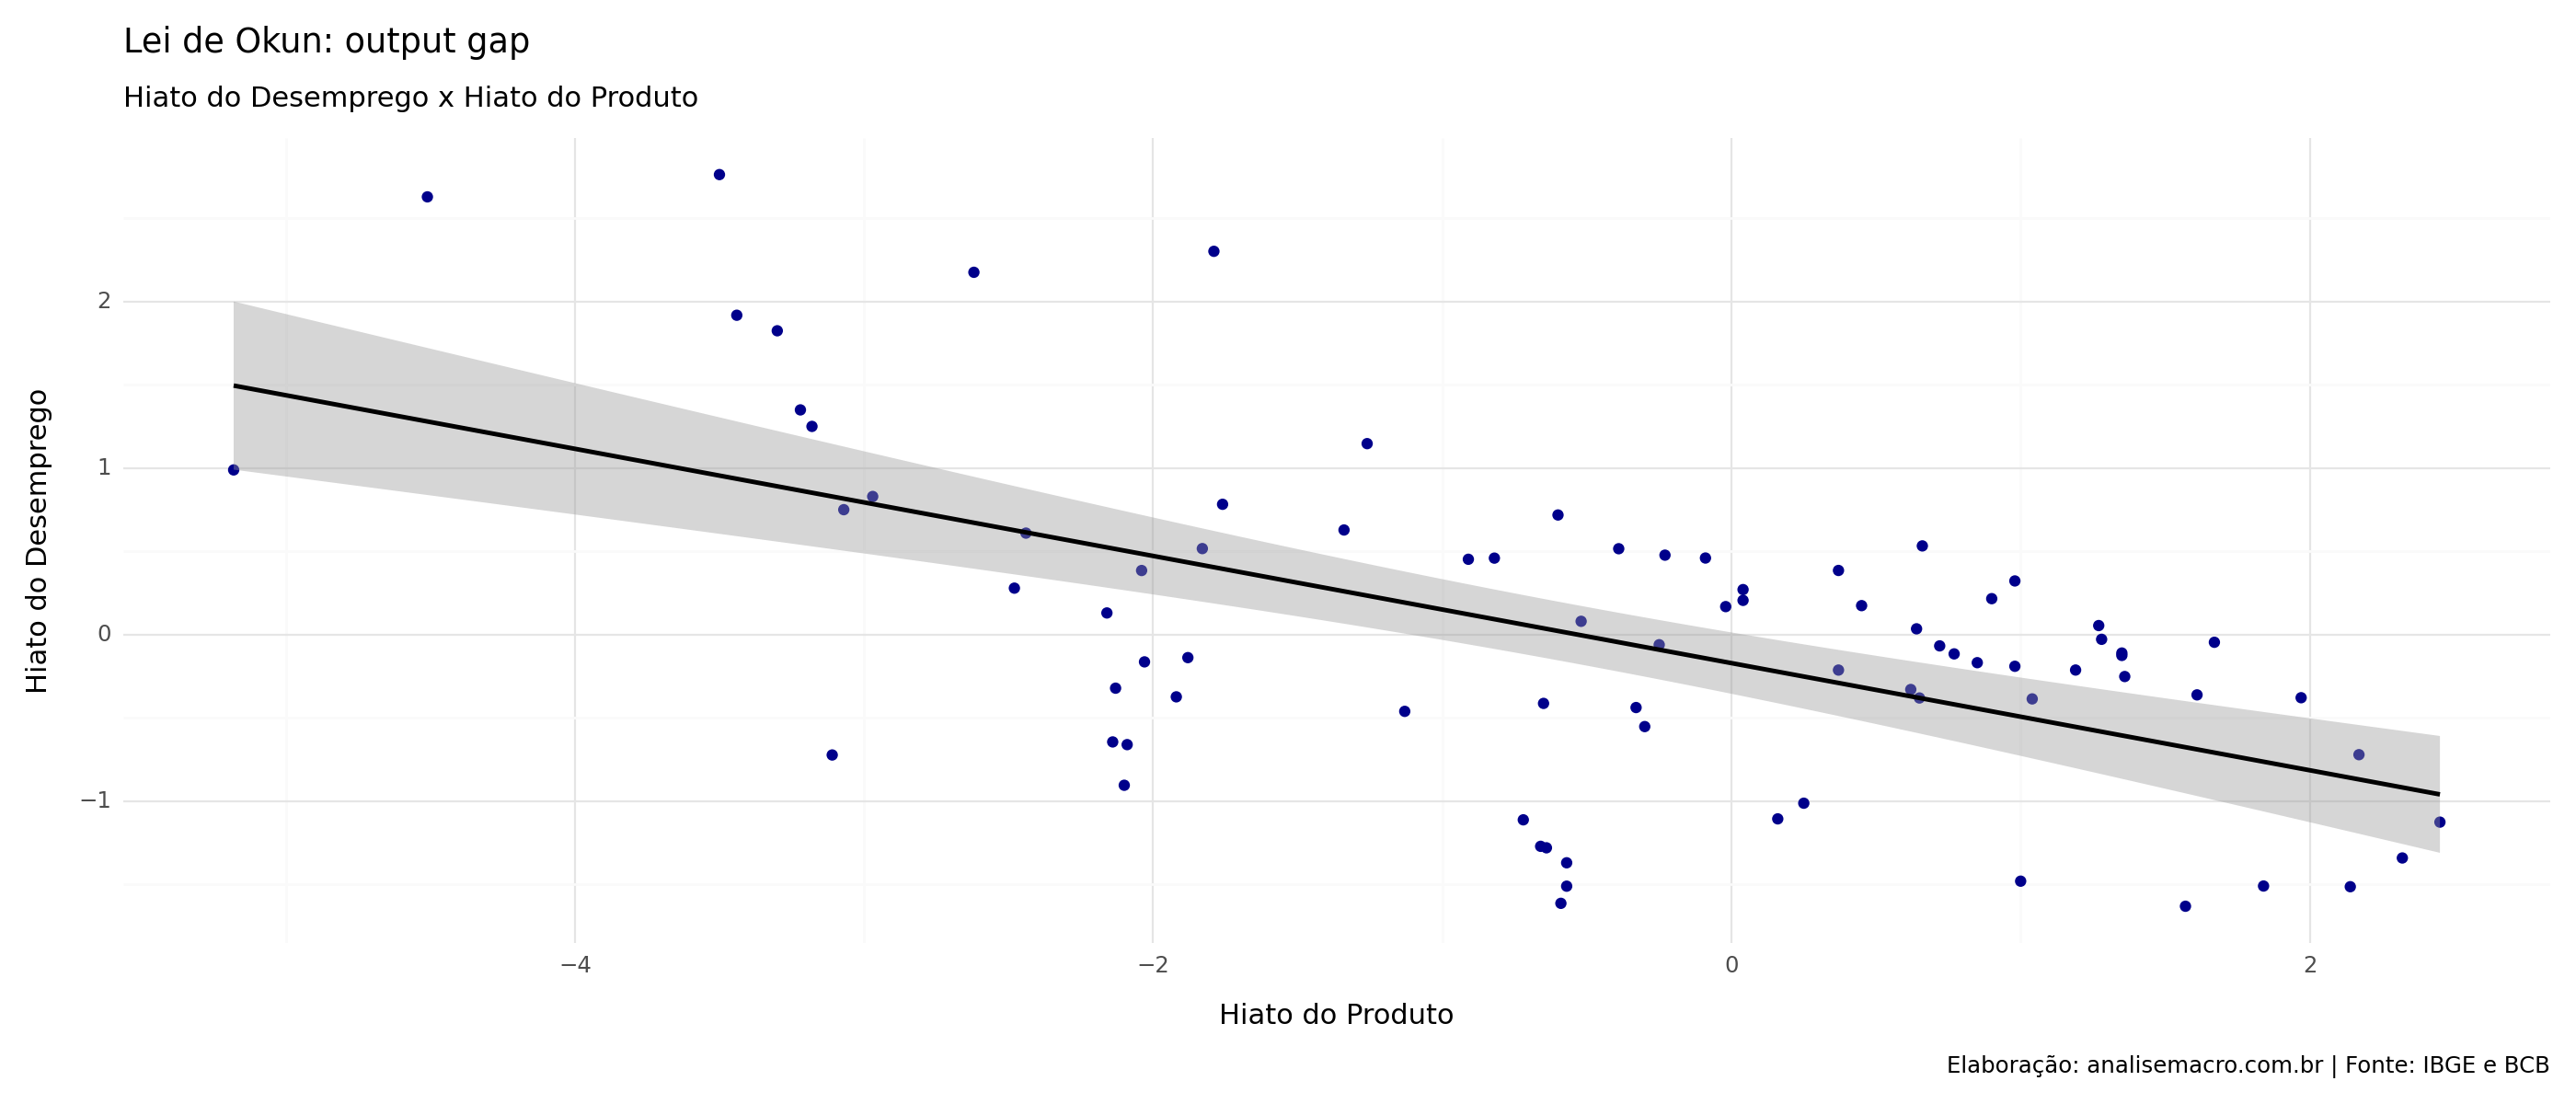

<Figure Size: (1400 x 600)>

In [ ]:
# Cria o gráfico
(
 ggplot(dados_reg, aes(x = 'hiato', y = 'u_gap')) +
 geom_point(color = 'darkblue') +
 stat_smooth(method = "lm") +
  labs(title = f"Lei de Okun: output gap",
      subtitle = "Hiato do Desemprego x Hiato do Produto",
      color="",
      x = "Hiato do Produto",
      y = "Hiato do Desemprego",
      caption = "Elaboração: analisemacro.com.br | Fonte: IBGE e BCB")+
 theme_minimal() +
 theme(figure_size = (14, 6),
       legend_position = "bottom")
)

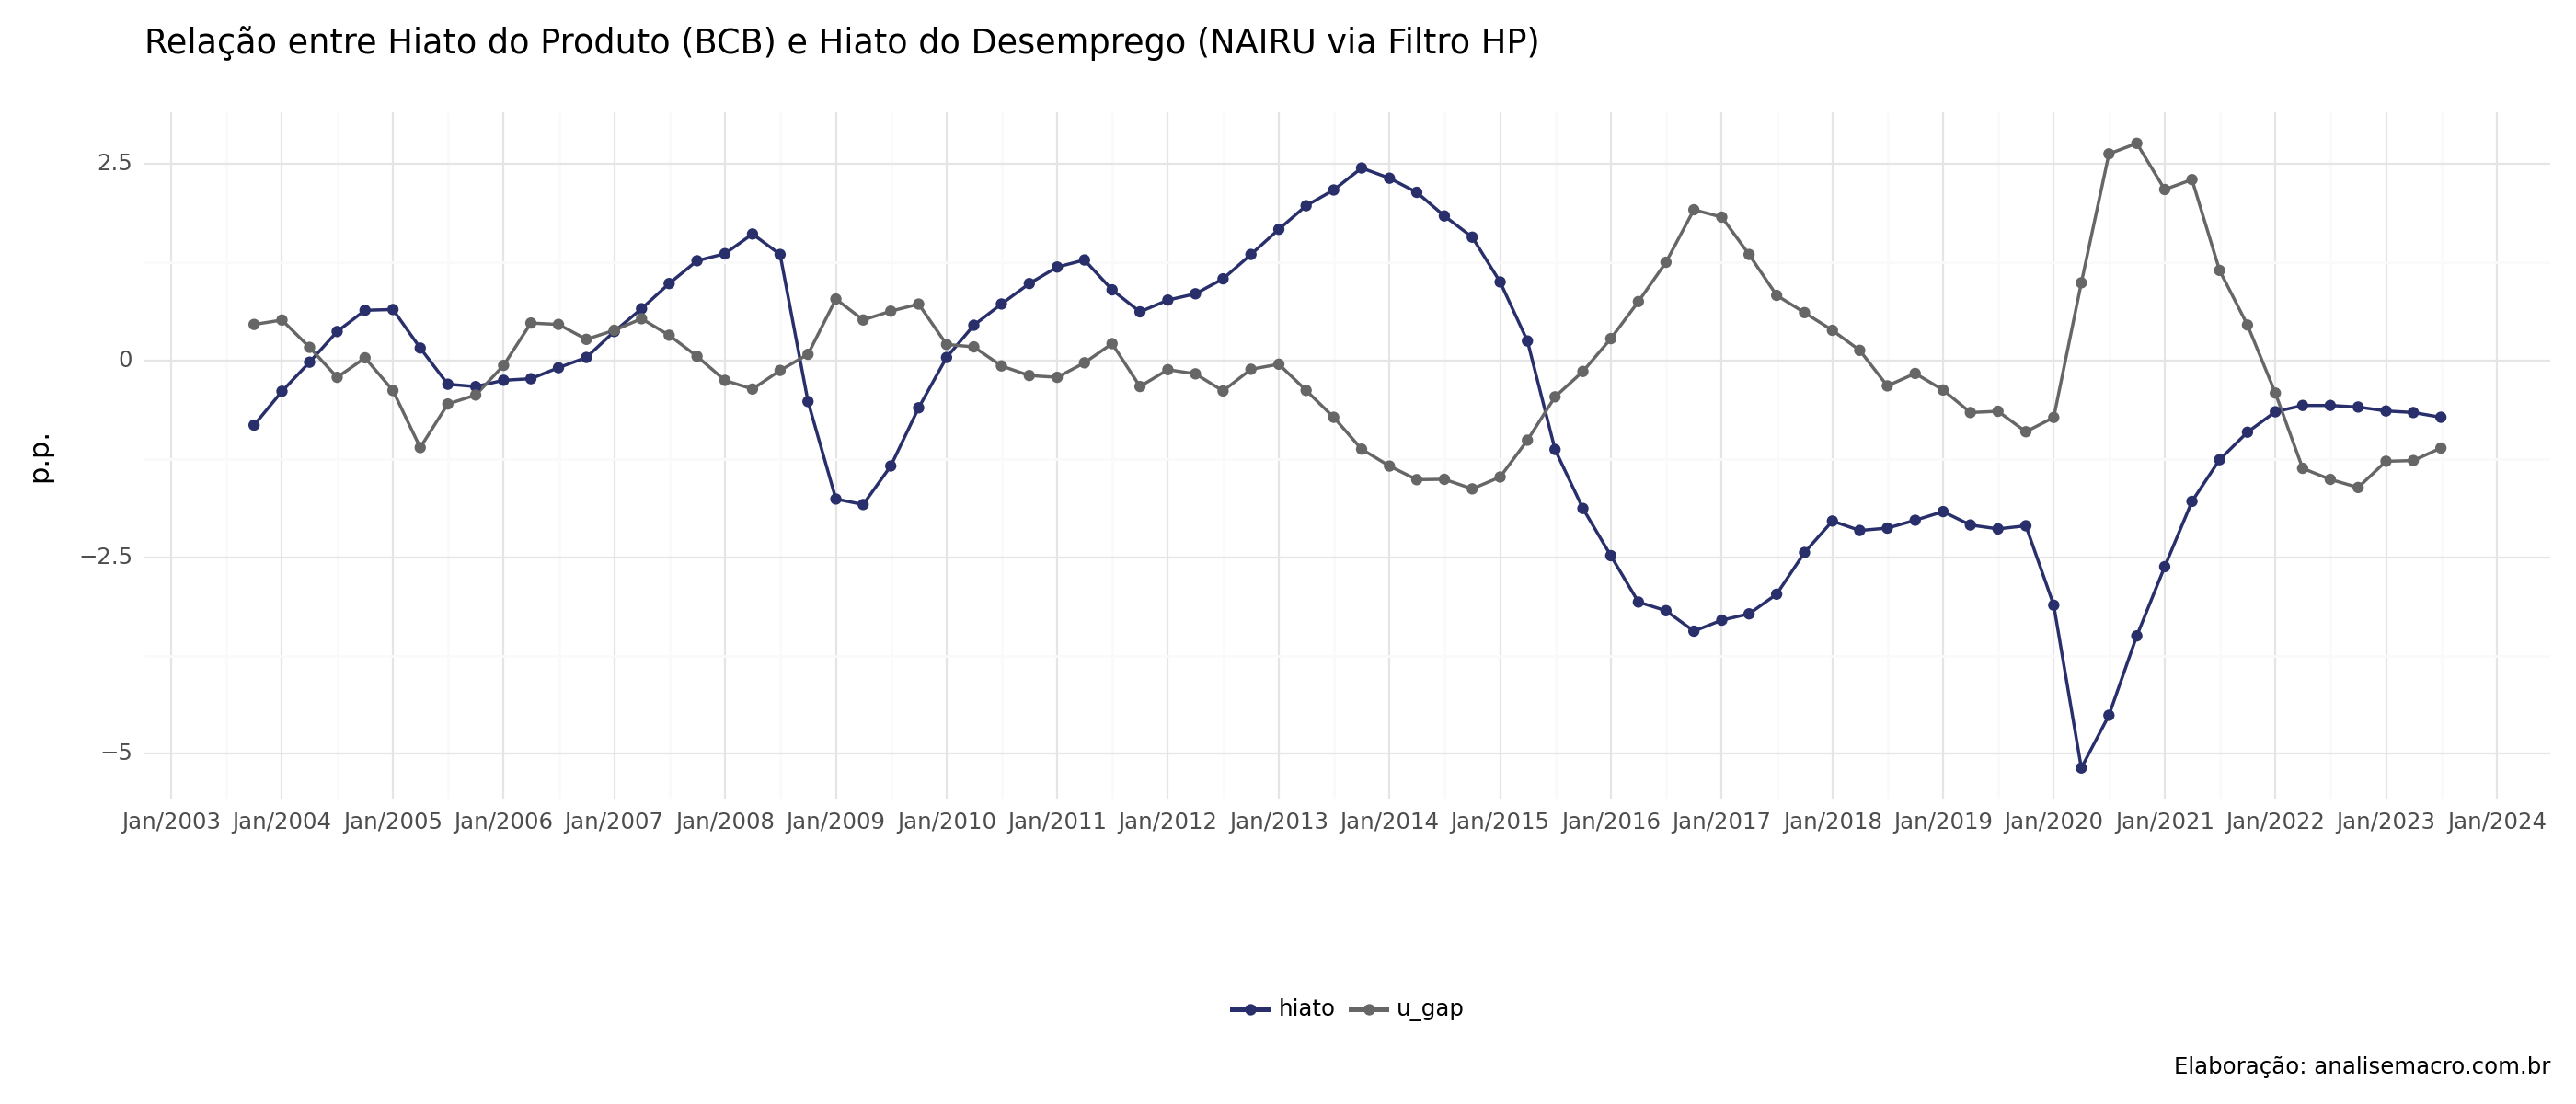

<Figure Size: (1400 x 600)>

In [ ]:
# Cria o gráfico
dados_gap_long = dados_reg[['Date', 'hiato', 'u_gap']].melt(id_vars = ['Date'])

# Cria o gráfico
# Cores para gráficos
colors = {'blue': '#282f6b',
          'gray': '#666666',
          'orange' : '#b35c1e'
          }

(
 ggplot(dados_gap_long, aes(x = 'Date', y = 'value', color = 'variable')) +
 geom_line(size = 0.7) +
 geom_point() +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "12 month", date_labels = "%b/%Y") +
 labs(title = f"Relação entre Hiato do Produto (BCB) e Hiato do Desemprego (NAIRU via Filtro HP)",
      color="",
      x="",
      y="p.p.",
      caption = "Elaboração: analisemacro.com.br")+
 theme_minimal() +
 theme(figure_size = (14, 6),
       legend_position = "bottom")
)

# Modelo Econométrico

## Modelo Estático

In [ ]:
# Estimando o modelo
model_gap = smf.ols('u_gap ~ 1 + hiato',
                    data = dados_reg).fit()

# Imprimindo o sumário do modelo
model_gap.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  u_gap   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     39.62
Date:                Wed, 10 Jan 2024   Prob (F-statistic):           1.67e-08
Time:                        19:40:59   Log-Likelihood:                -93.763
No. Observations:                  80   AIC:                             191.5
Df Residuals:                      78   BIC:                             196.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1707      0.093     -1.845      0.069      -0.355       0.013
hiato         -0.3218      0.051     -6.295      0.000      -0.424      -0.220
==============================================================================
Omnibus:                        0.596   Durbin-Watson:                   0.277
Prob(Omnibus):                  0.742   Jarque-Bera (JB):                0.731
Skew:                          -0.170   Prob(JB):                        0.694
Kurtosis:                       2.678   Cond. No.                         1.96
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Modelo em Janelas Deslizantes

In [ ]:
# Cria função para estimar regressão móvel
def roll_estimation(data, window_size, min_obs):

    result = (RollingOLS.from_formula(
      formula = "u_gap ~ 1 + hiato",
      data = data,
      window = window_size,
      min_nobs = min_obs
      )
      .fit()
      .params[["Intercept", "hiato"]]
    )

    result = pd.DataFrame(result).rename({"Intercept" : "Constante"}, axis = 1)
    result['Date'] = data['Date']
    return result

In [ ]:
# Cria a estimativa
okun_roll = roll_estimation(dados_reg, window_size = 52, min_obs = 48).dropna()

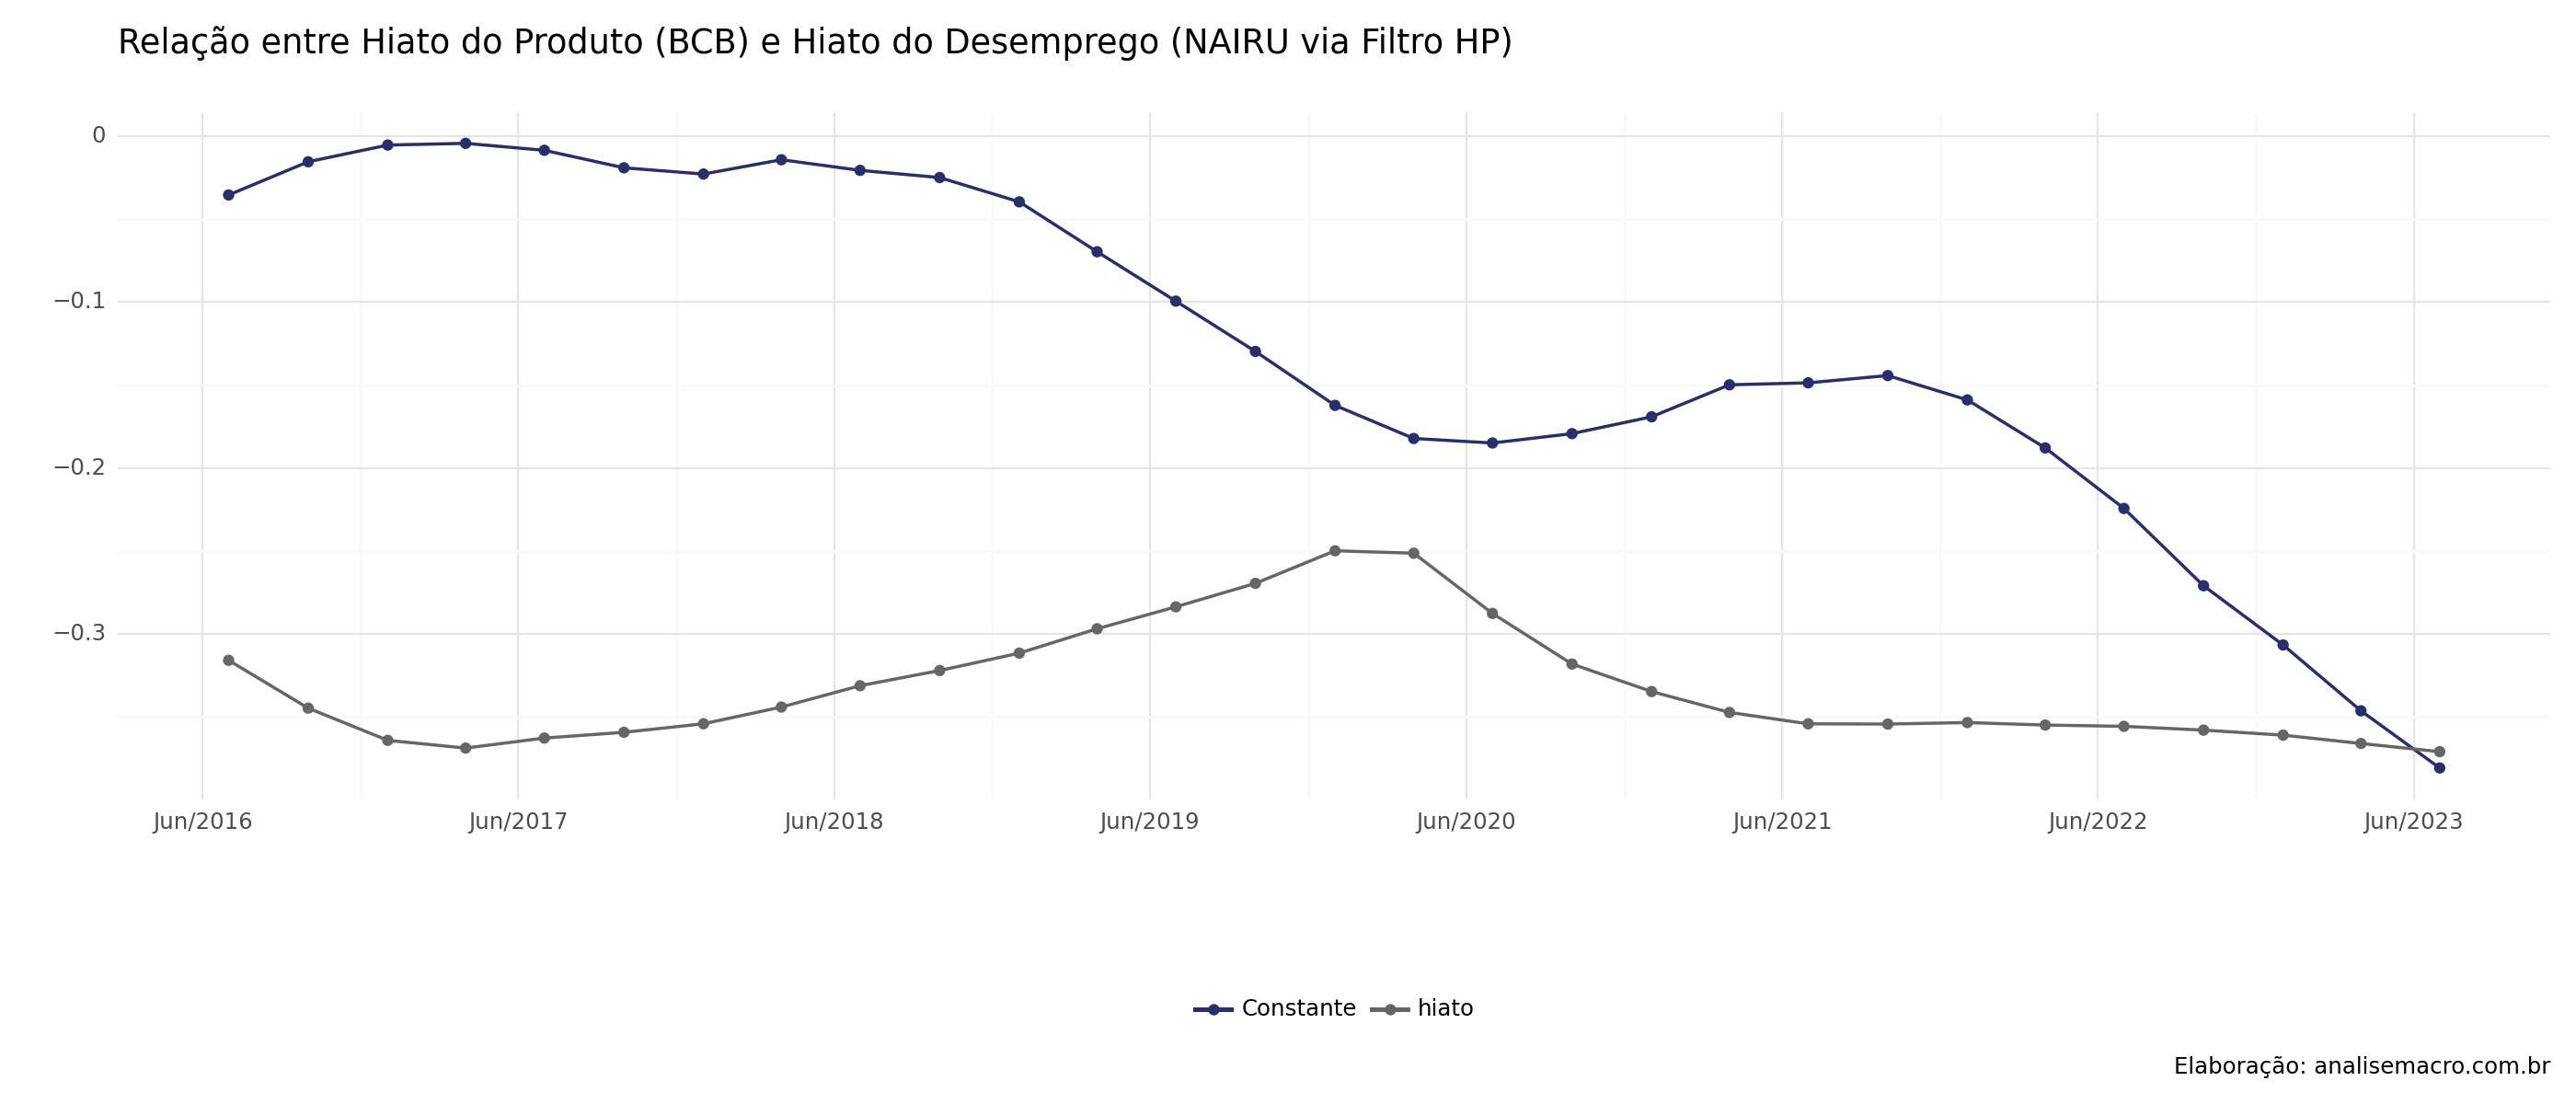

<Figure Size: (1400 x 600)>

In [ ]:
# Cria o gráfico
okun_roll_long = okun_roll[['Date', 'Constante', 'hiato']].melt(id_vars = ['Date'])

# Cria o gráfico
# Cores para gráficos
colors = {'blue': '#282f6b',
          'gray': '#666666',
          'orange' : '#b35c1e'
          }

(
 ggplot(okun_roll_long, aes(x = 'Date', y = 'value', color = 'variable')) +
 geom_line(size = 0.7) +
 geom_point() +
 scale_colour_manual(values = list(colors.values())) +
 scale_x_date(date_breaks = "12 month", date_labels = "%b/%Y") +
 labs(title = f"Relação entre Hiato do Produto (BCB) e Hiato do Desemprego (NAIRU via Filtro HP)",
      color="",
      x="",
      y="",
      caption = "Elaboração: analisemacro.com.br")+
 theme_minimal() +
 theme(figure_size = (14, 6),
       legend_position = "bottom")
)

# Considerações

Por mais que a Lei de Okun tenha seus defeitos, ainda pode servir de regra de bolso para o caso brasileiro, permitindo tornar as análises da relação do desemprego e do produto mais críveis.